In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA

from trajan.data import TracksDataFrame
from trajan.features import compute_trajectory_features

warnings.filterwarnings('ignore')
SEED = 42
DT_RANGE = (50, 120)  # must match GCN training config
N_SAMPLES_PER_TRACK = 10

## 1. Data loading and feature computation
Computes features on **full trajectories** and on **random subtrajectories** of length sampled
from `DT_RANGE`, matching the GCN training setup for a fair comparison.

In [3]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")
data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

# Full trajectory features
features_df = data.compute_features()

# Sampled subtrajectory features — matches GCN training setup
def compute_features_sampled(
    df: TracksDataFrame,
    Dt_range: tuple,
    n_samples_per_track: int = 10,
    seed: int = 42,
) -> pd.DataFrame:
    """Compute features from randomly sampled subtrajectories.

    Parameters
    ----------
    df : TracksDataFrame
        Tracking data.
    Dt_range : tuple[int, int]
        Min and max subtrajectory length in frames, matching the GCN setup.
    n_samples_per_track : int, optional
        Number of random windows to sample per trajectory. Default is 10.
    seed : int, optional
        Random seed. Default is 42.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for video in df['set'].unique():
        df_video = df[df['set'] == video]
        for label in df_video['label'].unique():
            track = df_video[df_video['label'] == label].sort_values('frame')
            coords = track[['x', 'y']].to_numpy()
            T = len(coords)

            for _ in range(n_samples_per_track):
                Dt = int(rng.integers(Dt_range[0], Dt_range[1] + 1))
                if T < Dt:
                    continue
                start = int(rng.integers(0, T - Dt + 1))
                sub_coords = coords[start:start + Dt]

                features = compute_trajectory_features(sub_coords, frame_rate=df.frame_rate)
                features['set'] = video
                features['label'] = label
                if 'type' in df.columns:
                    features['type'] = track['type'].iloc[0]
                rows.append(features)

    return pd.DataFrame(rows)

features_sampled_df = compute_features_sampled(data, DT_RANGE, N_SAMPLES_PER_TRACK, SEED)

print(f"Full trajectory features:    {len(features_df)} trajectories")
print(f"Sampled subtrajectory features: {len(features_sampled_df)} samples")
print(f"  ({N_SAMPLES_PER_TRACK} samples x {features_df['type'].value_counts().to_dict()} trajectories)")

Full trajectory features:    573 trajectories
Sampled subtrajectory features: 3239 samples
  (10 samples x {'endosome': 339, 'postgolgi': 131, 'golgi': 103} trajectories)


In [4]:
FEATURE_COLS = [
    # Diffusion
    'mean_speed', 'std_speed', 'alpha', 'diffusion_coeff', 'confinement_index',
    # Confinement
    'radius_of_gyration', 'max_displacement', 'net_displacement',
    'confinement_ratio', 'pause_fraction',
    # Directionality
    'velocity_autocorr_lag1', 'vacf_decay', 'straightness',
    'mean_turning_angle', 'std_turning_angle',
    'directionality_ratio_short', 'directionality_ratio_mid',
    # Local alpha
    'mean_local_alpha', 'std_local_alpha', 'range_local_alpha',
    # Statistical
    'non_gaussianity', 'kurtosis', 'turning_angle_entropy',
    # Asymmetry
    'asymmetry',
]

features_clean = features_df.dropna(subset=FEATURE_COLS).copy()
features_sampled_clean = features_sampled_df.dropna(subset=FEATURE_COLS).copy()

print(f"Full — after dropping NaNs: {len(features_clean)} / {len(features_df)}")
print(f"Sampled — after dropping NaNs: {len(features_sampled_clean)} / {len(features_sampled_df)}")
print(f"\nFull class distribution:")
print(features_clean['type'].value_counts())
print(f"\nSampled class distribution:")
print(features_sampled_clean['type'].value_counts())

Full — after dropping NaNs: 525 / 573
Sampled — after dropping NaNs: 3239 / 3239

Full class distribution:
type
endosome     296
postgolgi    130
golgi         99
Name: count, dtype: int64

Sampled class distribution:
type
endosome     1748
postgolgi     771
golgi         720
Name: count, dtype: int64


## 2. Feature exploration
Distributions and pairplot on full trajectory features.

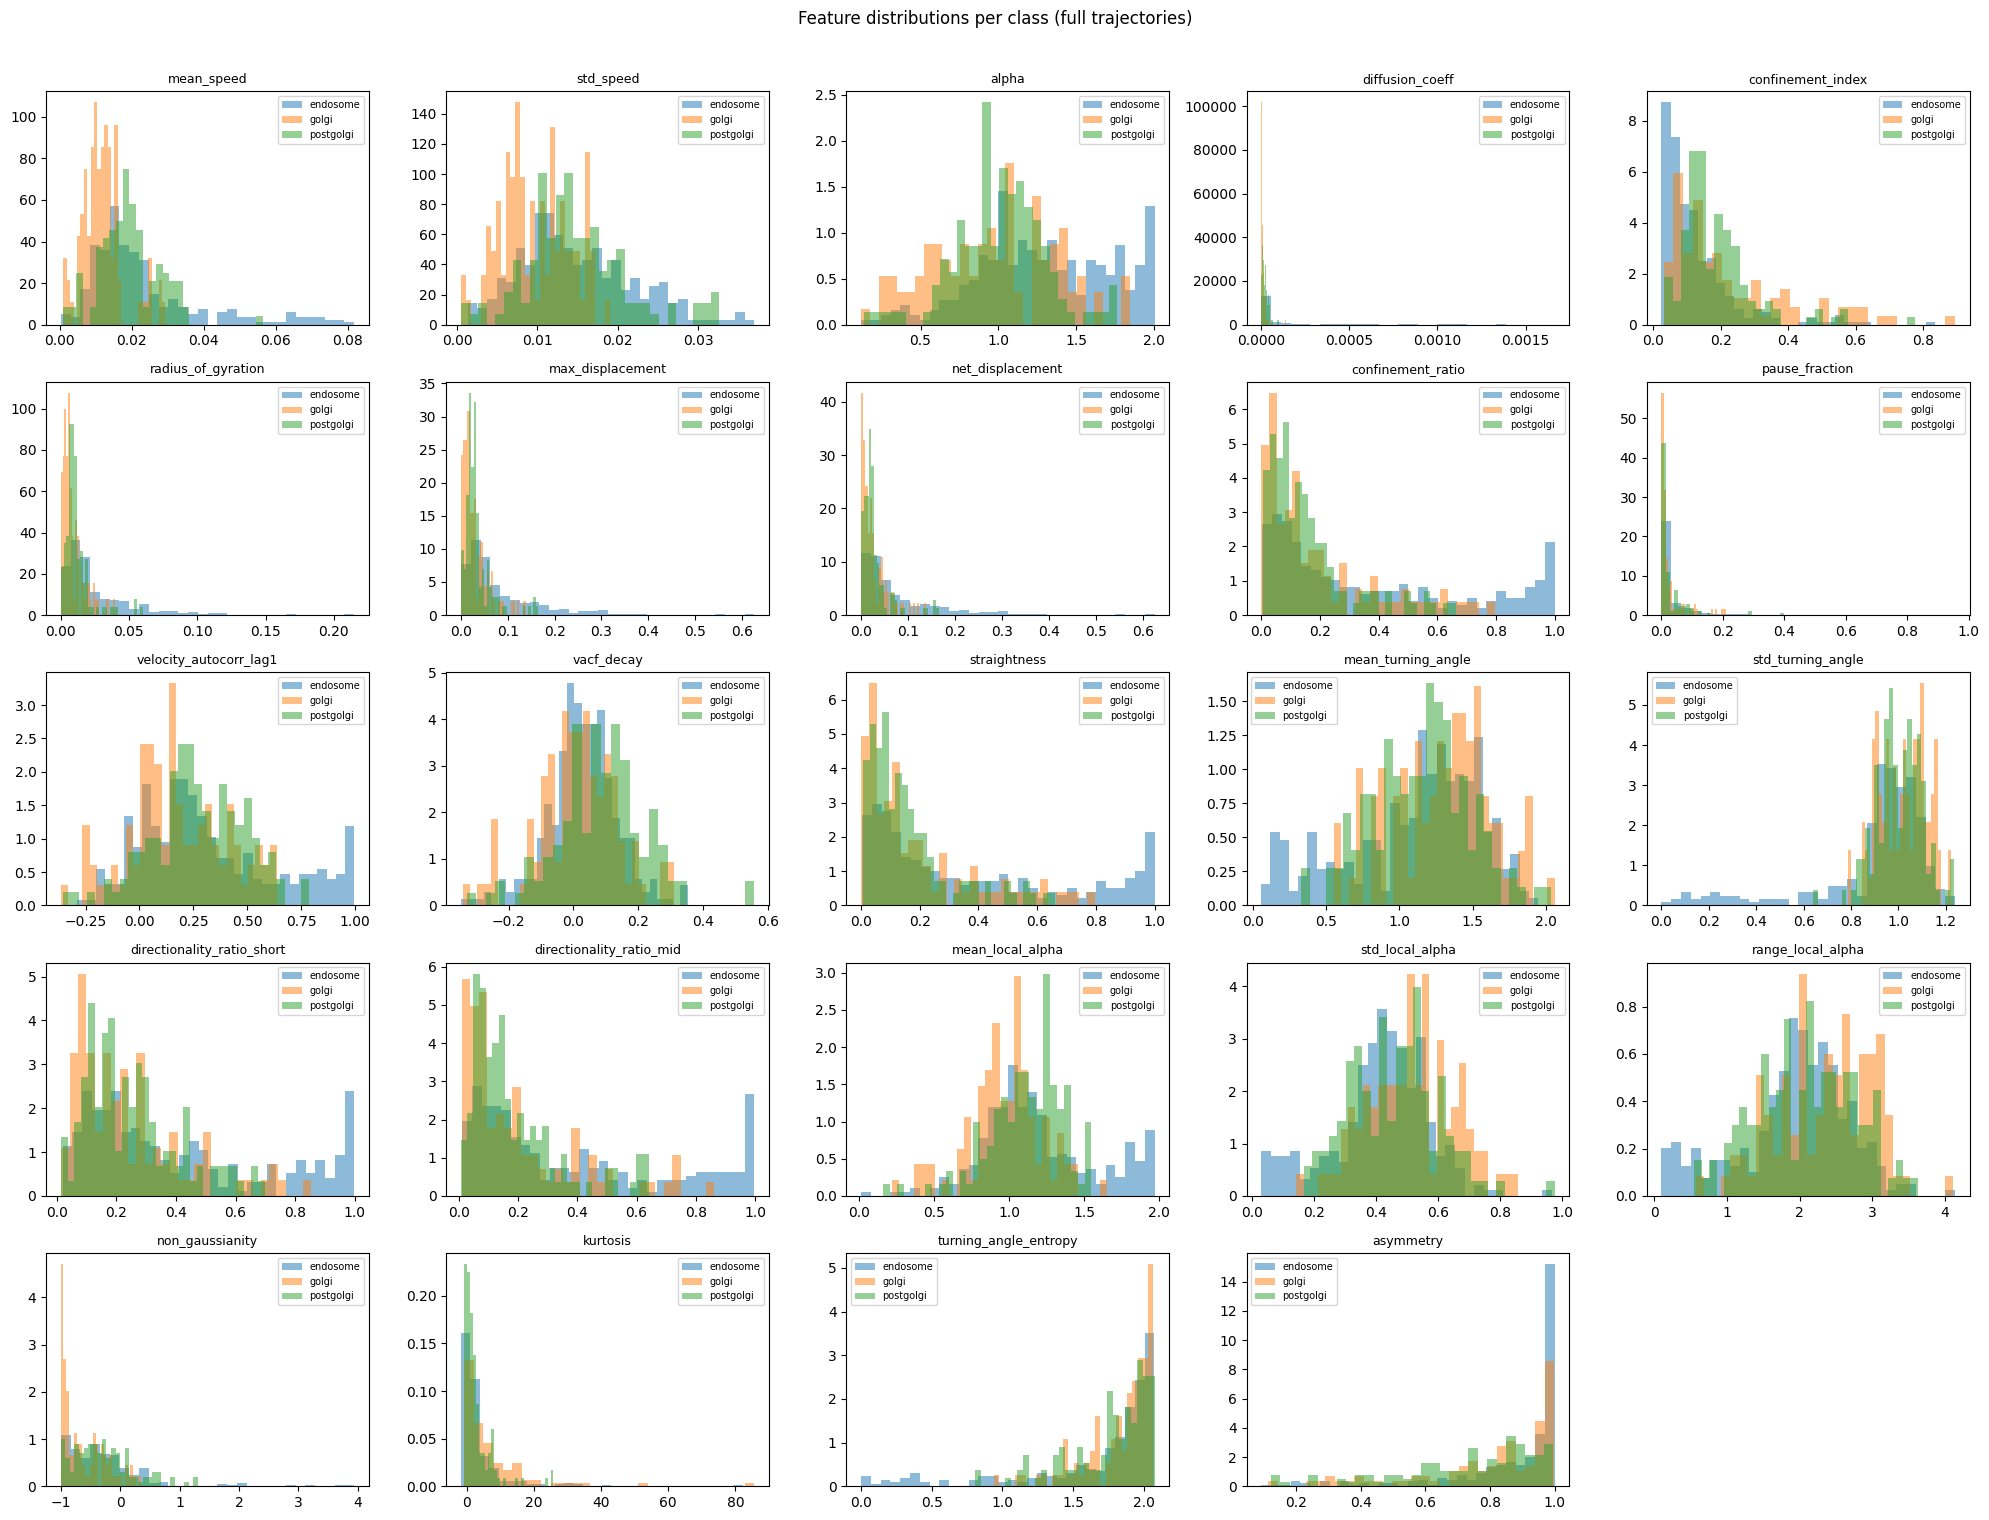

In [5]:
n_cols = 5
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for particle_type in features_clean['type'].unique():
        vals = features_clean[features_clean['type'] == particle_type][feat].dropna()
        axes[i].hist(vals, bins=30, alpha=0.5, label=particle_type, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions per class (full trajectories)', y=1.01)
plt.tight_layout()
plt.show()

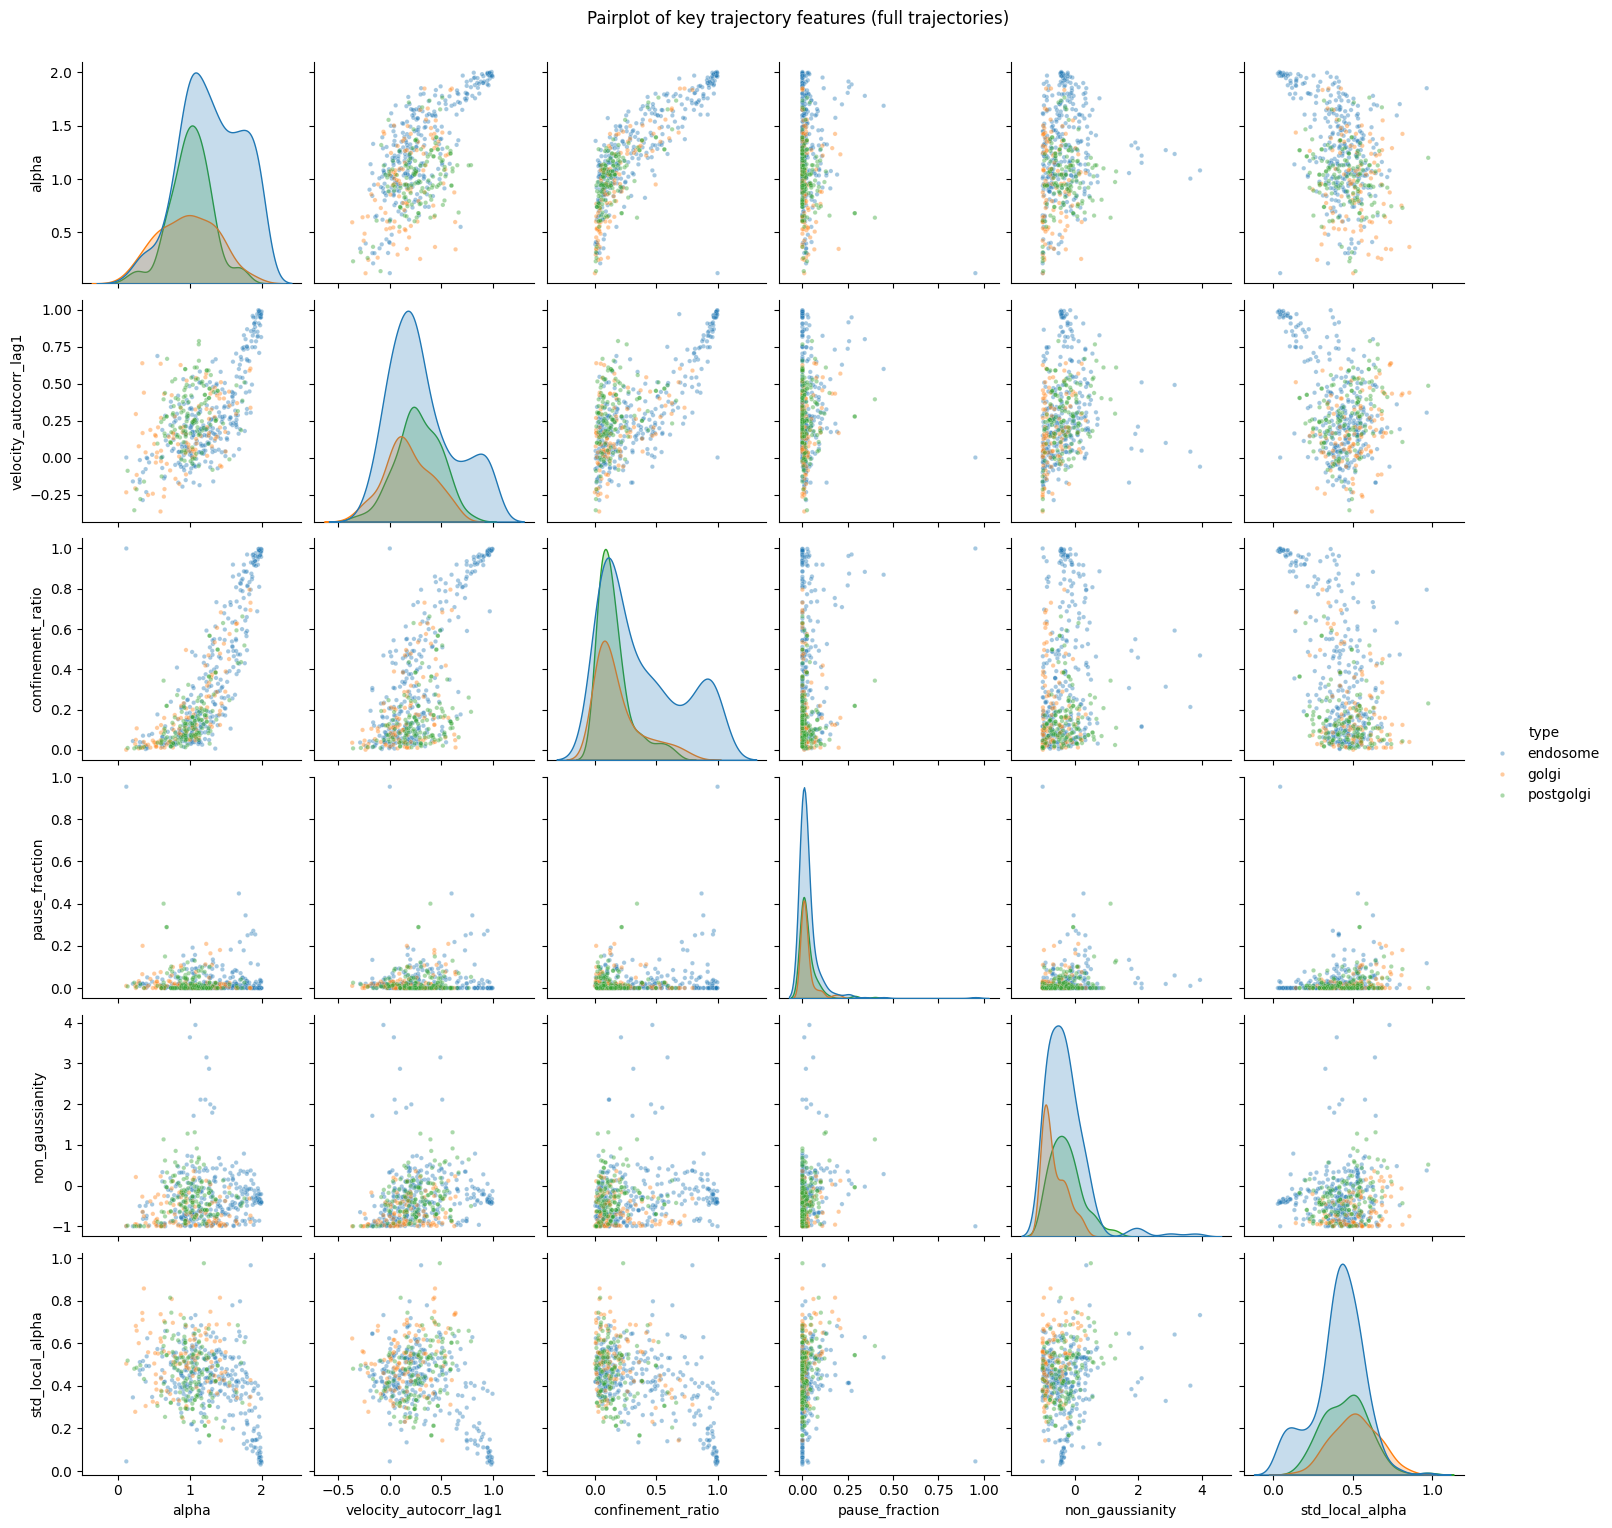

In [6]:
key_features = [
    'alpha', 'velocity_autocorr_lag1', 'confinement_ratio',
    'pause_fraction', 'non_gaussianity', 'std_local_alpha', 'type'
]
sns.pairplot(features_clean[key_features].dropna(), hue='type', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot of key trajectory features (full trajectories)', y=1.02)
plt.show()

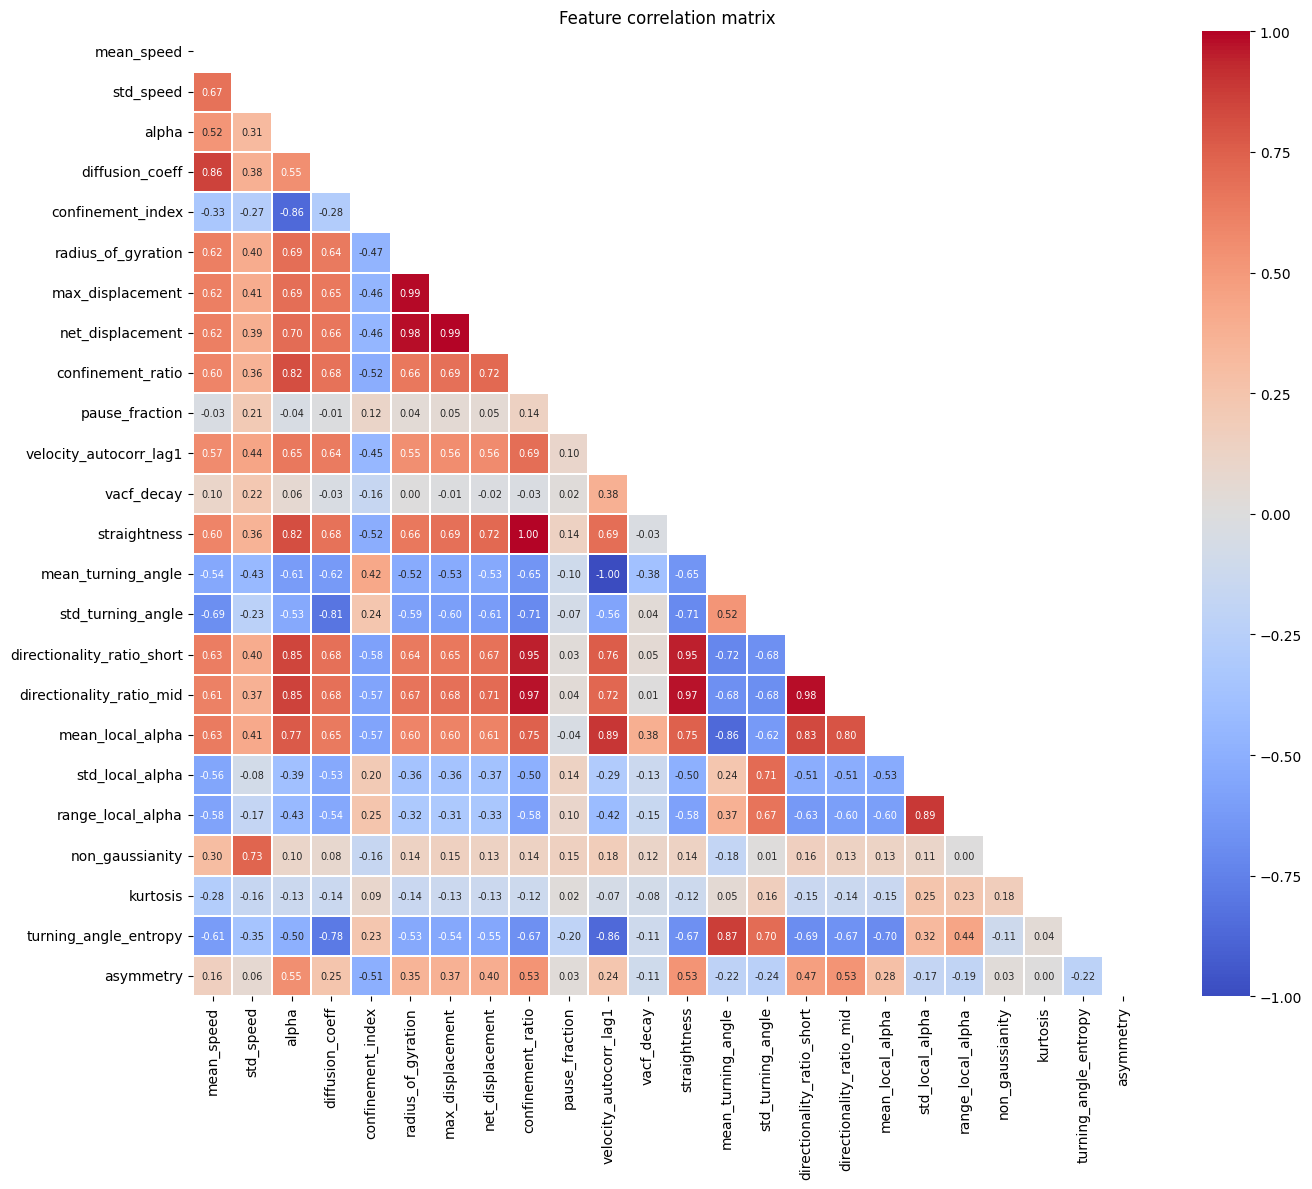

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_clean[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7}, linewidths=0.3,
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## 3. PCA
Side-by-side PCA for full and sampled features — shows whether subtrajectory sampling preserves class separability in feature space.

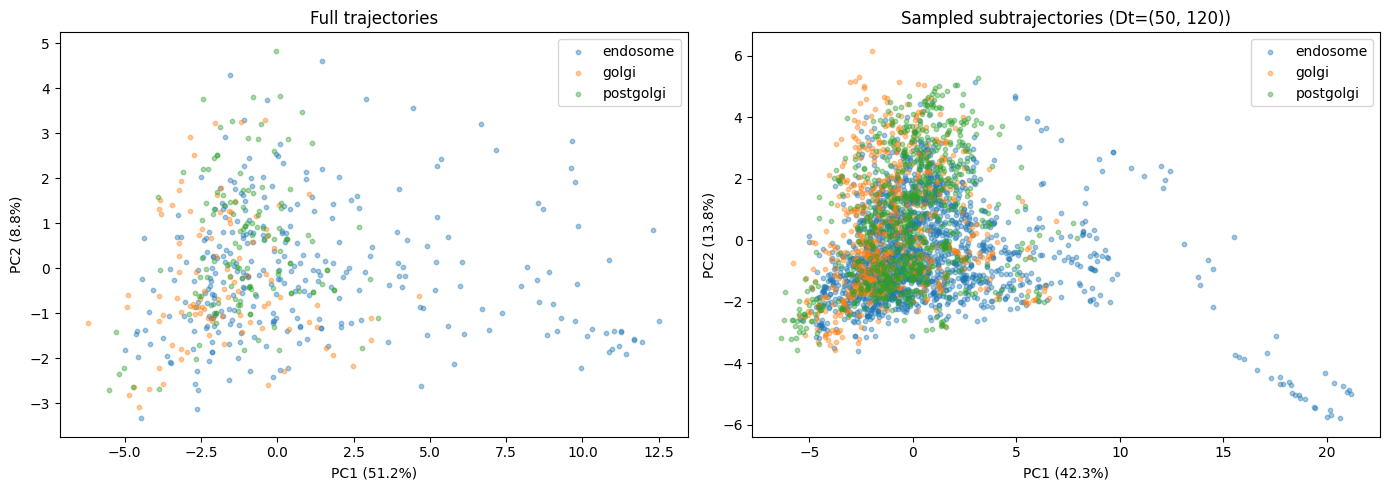

In [8]:
le = LabelEncoder()
le.fit(features_clean['type'].values)
class_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(
    axes,
    [features_clean, features_sampled_clean],
    ['Full trajectories', f'Sampled subtrajectories (Dt={DT_RANGE})'],
):
    X = df[FEATURE_COLS].values
    y_enc = le.transform(df['type'].values)

    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)

    for i, cls in enumerate(class_names):
        mask = y_enc == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.4, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Train/test split
Recording-wise split, consistent with the GCN pipeline. Applied to both full and sampled features.

In [9]:
rng = np.random.default_rng(SEED)
test_recordings = []

for particle_type in features_clean['type'].unique():
    recordings = features_clean[features_clean['type'] == particle_type]['set'].unique()
    n_test = max(1, int(round(len(recordings) * 0.25)))
    test_recordings.extend(rng.choice(recordings, n_test, replace=False).tolist())

# Full trajectory split
train_full = features_clean[~features_clean['set'].isin(test_recordings)]
test_full = features_clean[features_clean['set'].isin(test_recordings)]

X_train_full = train_full[FEATURE_COLS].values
y_train_full = le.transform(train_full['type'].values)
X_test_full = test_full[FEATURE_COLS].values
y_test_full = le.transform(test_full['type'].values)

# Sampled subtrajectory split — same recording-level split
train_sampled = features_sampled_clean[~features_sampled_clean['set'].isin(test_recordings)]
test_sampled = features_sampled_clean[features_sampled_clean['set'].isin(test_recordings)]

X_train_sampled = train_sampled[FEATURE_COLS].values
y_train_sampled = le.transform(train_sampled['type'].values)
X_test_sampled = test_sampled[FEATURE_COLS].values
y_test_sampled = le.transform(test_sampled['type'].values)

print(f"Full     — Train: {len(X_train_full)}, Test: {len(X_test_full)}")
print(f"Sampled  — Train: {len(X_train_sampled)}, Test: {len(X_test_sampled)}")

Full     — Train: 408, Test: 117
Sampled  — Train: 2487, Test: 752


## 5. Model training and cross-validation
Models trained and evaluated on both full and sampled features for a fair comparison with the GCN.

In [10]:
def make_pipelines():
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=SEED
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', class_weight='balanced', probability=True, random_state=SEED
        ),
        'KNN': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    }
    return {
        name: Pipeline([('scaler', StandardScaler()), ('model', model)])
        for name, model in models.items()
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def run_cv(pipelines, X, y, label):
    print(f"\n{'='*50}")
    print(f"Cross-validation: {label}")
    print('='*50)
    results = {}
    for name, pipeline in pipelines.items():
        scores = cross_validate(
            pipeline, X, y, cv=cv,
            scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
            return_train_score=True,
        )
        results[name] = scores
        print(f"{name}")
        print(f"  val balanced accuracy: {scores['test_balanced_accuracy'].mean():.3f} "
              f"± {scores['test_balanced_accuracy'].std():.3f}")
        print(f"  val macro F1:          {scores['test_f1_macro'].mean():.3f} "
              f"± {scores['test_f1_macro'].std():.3f}")
    return results

pipelines_full    = make_pipelines()
pipelines_sampled = make_pipelines()

cv_results_full    = run_cv(pipelines_full,    X_train_full,    y_train_full,    'Full trajectories')
cv_results_sampled = run_cv(pipelines_sampled, X_train_sampled, y_train_sampled, f'Sampled (Dt={DT_RANGE})')


Cross-validation: Full trajectories


Random Forest
  val balanced accuracy: 0.586 ± 0.049
  val macro F1:          0.601 ± 0.057
Gradient Boosting
  val balanced accuracy: 0.553 ± 0.076
  val macro F1:          0.554 ± 0.089
SVM (RBF)
  val balanced accuracy: 0.646 ± 0.017
  val macro F1:          0.570 ± 0.020
KNN
  val balanced accuracy: 0.445 ± 0.035
  val macro F1:          0.441 ± 0.048

Cross-validation: Sampled (Dt=(50, 120))
Random Forest
  val balanced accuracy: 0.740 ± 0.008
  val macro F1:          0.784 ± 0.008
Gradient Boosting
  val balanced accuracy: 0.727 ± 0.016
  val macro F1:          0.762 ± 0.013
SVM (RBF)
  val balanced accuracy: 0.741 ± 0.010
  val macro F1:          0.697 ± 0.014
KNN
  val balanced accuracy: 0.687 ± 0.012
  val macro F1:          0.720 ± 0.017


In [11]:
def make_summary(cv_results):
    return pd.DataFrame({
        name: {
            'val_accuracy': scores['test_accuracy'].mean(),
            'val_balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'val_f1_macro': scores['test_f1_macro'].mean(),
            'train_accuracy': scores['train_accuracy'].mean(),
        }
        for name, scores in cv_results.items()
    }).T.round(3)

summary_full    = make_summary(cv_results_full)
summary_sampled = make_summary(cv_results_sampled)

print('Full trajectories:')
display(summary_full)
print('\nSampled subtrajectories:')
display(summary_sampled)

Full trajectories:


,val_accuracy,val_balanced_accuracy,val_f1_macro,train_accuracy
Random Forest,0.750,0.586,0.601,1.000
Gradient Boosting,0.696,0.553,0.554,1.000
SVM (RBF),0.608,0.646,0.570,0.679
KNN,0.664,0.445,0.441,0.744



Sampled subtrajectories:


,val_accuracy,val_balanced_accuracy,val_f1_macro,train_accuracy
Random Forest,0.841,0.740,0.784,1.000
Gradient Boosting,0.825,0.727,0.762,0.981
SVM (RBF),0.729,0.741,0.697,0.761
KNN,0.797,0.687,0.720,0.843


## 6. Evaluation on held-out test set
Side-by-side confusion matrices for full vs sampled features, for each model.

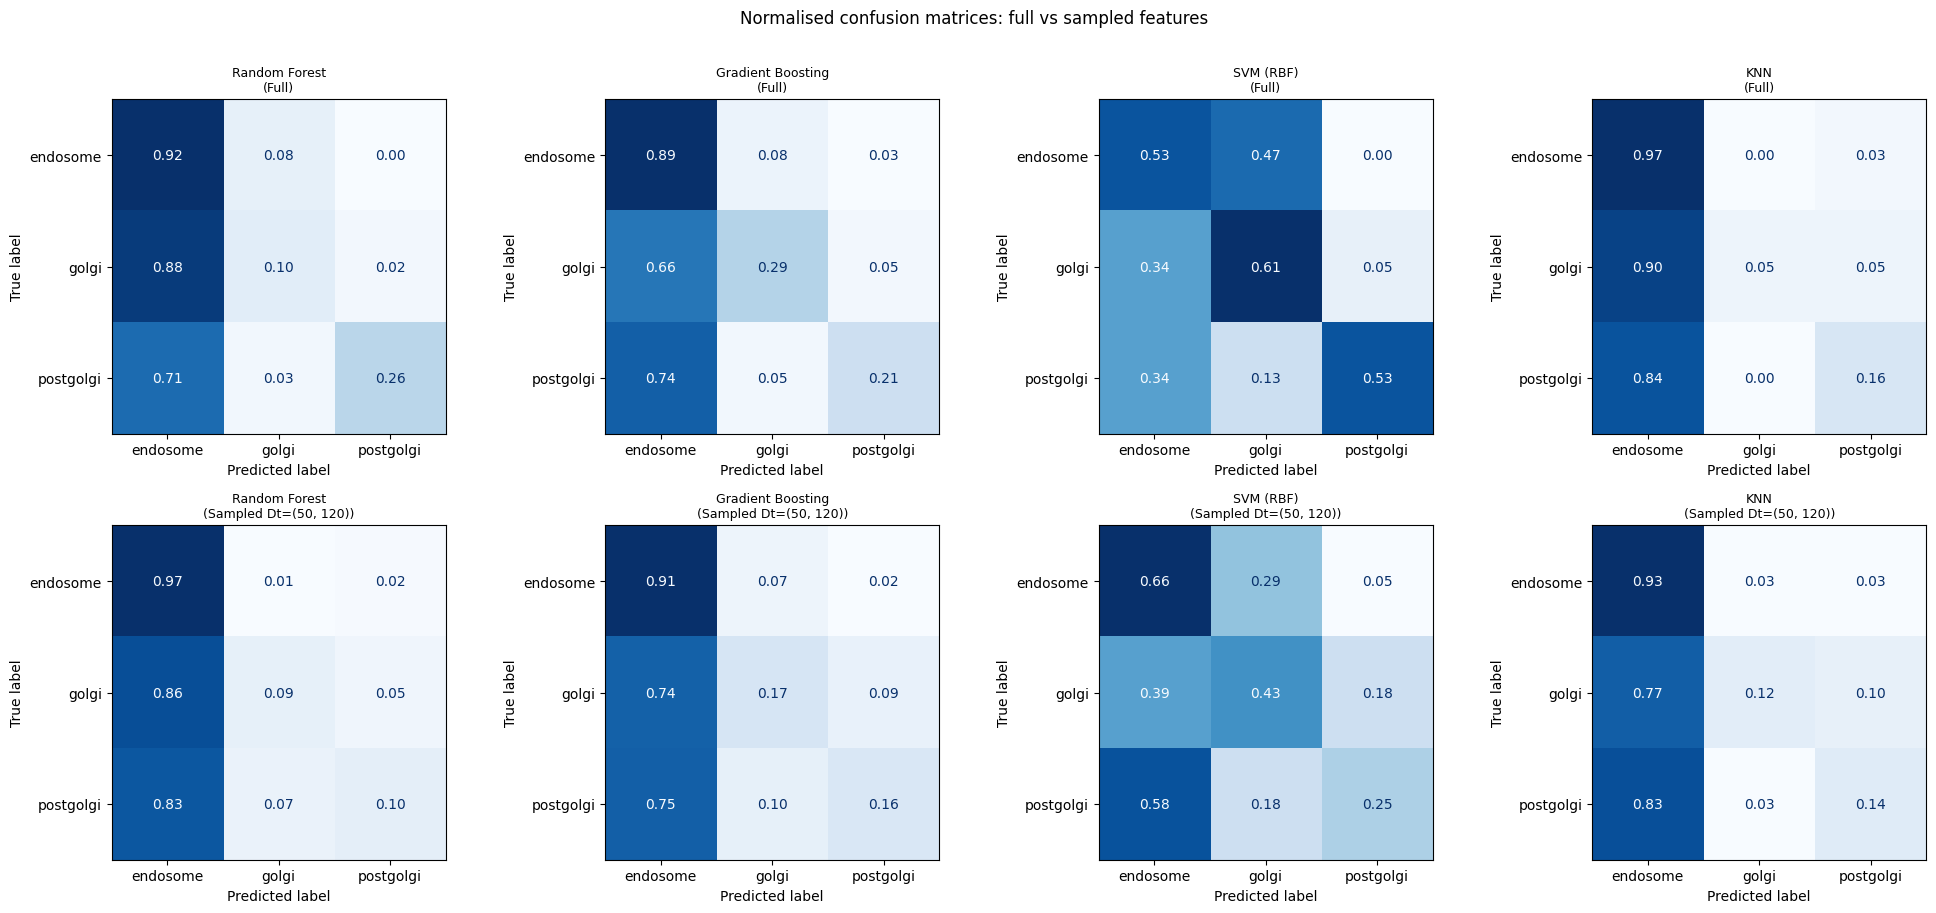

In [12]:
model_names = list(pipelines_full.keys())
n_models = len(model_names)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))

for col, name in enumerate(model_names):
    for row, (pipelines, X_train, y_train, X_test, y_test, label) in enumerate([
        (pipelines_full,    X_train_full,    y_train_full,    X_test_full,    y_test_full,    'Full'),
        (pipelines_sampled, X_train_sampled, y_train_sampled, X_test_sampled, y_test_sampled, f'Sampled Dt={DT_RANGE}'),
    ]):
        pipelines[name].fit(X_train, y_train)
        y_pred = pipelines[name].predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
            ax=axes[row, col], cmap='Blues', values_format='.2f', colorbar=False
        )
        axes[row, col].set_title(f'{name}\n({label})', fontsize=9)

plt.suptitle('Normalised confusion matrices: full vs sampled features', y=1.01)
plt.tight_layout()
plt.show()

## 7. Feature importance (Random Forest)
Comparison of feature importances between full and sampled trajectory features.

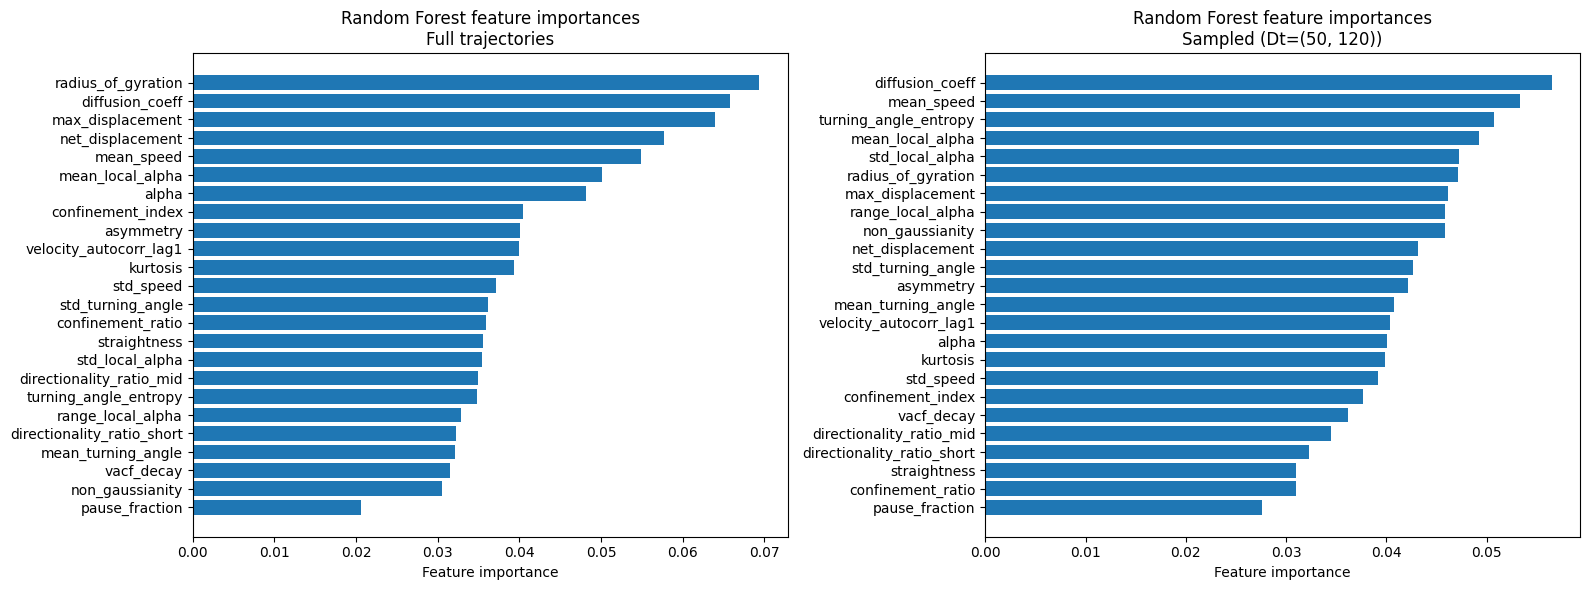

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pipelines, title in zip(
    axes,
    [pipelines_full, pipelines_sampled],
    ['Full trajectories', f'Sampled (Dt={DT_RANGE})'],
):
    importances = pipelines['Random Forest'].named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    importance_df = importance_df.sort_values('importance', ascending=True)
    ax.barh(importance_df['feature'], importance_df['importance'])
    ax.set_xlabel('Feature importance')
    ax.set_title(f'Random Forest feature importances\n{title}')

plt.tight_layout()
plt.show()

## 8. Separability assessment
Summary comparing full vs sampled trajectory separability, and what this implies for the GCN.

In [14]:
for summary, label in [
    (summary_full,    'Full trajectories'),
    (summary_sampled, f'Sampled (Dt={DT_RANGE})'),
]:
    best_model = summary['val_balanced_accuracy'].idxmax()
    best_score = summary.loc[best_model, 'val_balanced_accuracy']
    print(f"{label}")
    print(f"  Best model: {best_model} — balanced accuracy: {best_score:.3f}")
    if best_score < 0.5:
        print("  Classes appear not separable from trajectory features alone.")
    elif best_score < 0.7:
        print("  Weak separability. GNN may improve but gains may be limited.")
    else:
        print("  Classes are separable. GNN has room to improve further.")
    print()

Full trajectories
  Best model: SVM (RBF) — balanced accuracy: 0.646
  Weak separability. GNN may improve but gains may be limited.

Sampled (Dt=(50, 120))
  Best model: SVM (RBF) — balanced accuracy: 0.741
  Classes are separable. GNN has room to improve further.

